# LLR Comparison: Base ESM2 vs LoRA-Finetuned

Loads the LoRA delta weights produced by `ESM_domainome_ft.ipynb`, recomputes per-domain
LLR matrices with both the un-finetuned base model and the finetuned model, and uploads a
single dictionary `{domain_id: {sequence, seq_offset, base_llr, ft_llr, delta_llr, ...}}`
to GCS as a gzipped pickle.


In [34]:
import os
import io
from io import BytesIO
import gzip
import json
import pickle
import warnings
import logging

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm
from dotenv import load_dotenv
from transformers import EsmForMaskedLM, EsmTokenizer
from peft import LoraConfig, get_peft_model
from google.cloud import storage

warnings.filterwarnings("ignore")
logging.getLogger("transformers").setLevel(logging.ERROR)

In [8]:
# ── Constants (must match training run) ──────────────────────────────────────

AA_ORDER         = ['L', 'A', 'G', 'V', 'S', 'E', 'R', 'T', 'I', 'D',
                    'P', 'K', 'Q', 'N', 'F', 'Y', 'M', 'H', 'W', 'C']
FITNESS_AA_ORDER = list("ACDEFGHIKLMNPQRSTVWY")
MODEL_NAME       = "facebook/esm2_t33_650M_UR50D"
MAX_LEN          = 1022
LORA_DROPOUT     = 0.1

# ── Local + GCS layout (must match training run) ─────────────────────────────

OUTPUT_DIR = "finetuned_models_v2"
RUN_ID     = "global_finetune"
RUN_DIR    = os.path.join(OUTPUT_DIR, RUN_ID)
os.makedirs(RUN_DIR, exist_ok=True)

GCS_PROJECT           = "plm-study-484223"   # e.g. "my-gcp-project"
GCS_BUCKET            = "domainome-data"   # e.g. "my-bucket"
GCS_DOMAIN_DATA_BLOB  = "ESM2/dict_fitness.pkl.gz"   # e.g. "domainome/dict_fitness.pkl.gz"
GCS_FULL_PROTEIN_BLOB = "ESM2/dict_domainome_uniprot_new.pkl.gz"   # e.g. "domainome/full_proteins.pkl.gz"
GCS_OUTPUT_PREFIX     = "ESM2/ft_all_doms_run2/"   # e.g. "domainome/finetuned_models_v2/" (must end with /)

# Where the LoRA weights and metadata produced by training live in GCS.
GCS_LORA_BLOB     = f"{GCS_OUTPUT_PREFIX}{RUN_ID}/best_model_lora.pth"
GCS_METADATA_BLOB = f"{GCS_OUTPUT_PREFIX}{RUN_ID}/metadata.json"

# Where the LLR comparison dict will be uploaded.
LLR_OUTPUT_NAME    = "llr_comparison.pkl.gz"
LLR_LOCAL_PATH     = os.path.join(RUN_DIR, LLR_OUTPUT_NAME)
GCS_LLR_OUTPUT_KEY = f"{GCS_OUTPUT_PREFIX}{RUN_ID}/{LLR_OUTPUT_NAME}"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [9]:
# ── GCS Helpers ──────────────────────────────────────────────────────────────
load_dotenv()
cred_path = os.getenv('GOOGLE_APPLICATION_CREDENTIALS')

os.environ['GOOGLE_APPLICATION_CREDENTIALS'] = cred_path

# _gcs_client = storage.Client(project=GCS_PROJECT) if GCS_PROJECT else storage.Client()
_gcs_client = storage.Client()
_gcs_bucket = _gcs_client.bucket(GCS_BUCKET)


def gcs_download_pickle_gz(blob):
    data = blob.download_as_bytes()
    with gzip.GzipFile(fileobj=io.BytesIO(data), mode="rb") as gz:
        return pickle.load(gz)


def gcs_download_to_file(blob_path, local_path):
    blob = _gcs_bucket.blob(blob_path)
    os.makedirs(os.path.dirname(local_path), exist_ok=True)
    blob.download_to_filename(local_path)
    return local_path


def gcs_upload_file(blob_path, local_path, content_type="application/octet-stream"):
    blob = _gcs_bucket.blob(blob_path)
    blob.upload_from_filename(local_path, content_type=content_type)

In [10]:
# ── Helpers (mirrored from training notebook) ────────────────────────────────

def truncate_to_domain(sequence, domain_start, domain_end, max_len=MAX_LEN):
    seq_len    = len(sequence)
    domain_mid = (domain_start + domain_end) // 2
    half       = max_len // 2
    start      = max(0, domain_mid - 1 - half)
    end        = start + max_len
    if end > seq_len:
        end   = seq_len
        start = max(0, end - max_len)
    return sequence[start:end], start


def get_LLR_scores(sequence, model, tokenizer, device):
    seq_list  = list(sequence)
    tokenized = tokenizer(sequence, padding=False, truncation=True,
                          max_length=1024, return_tensors="pt")
    input_ids = tokenized["input_ids"].to(device)

    logits    = model(input_ids).logits
    log_probs = torch.log_softmax(logits, dim=-1)
    wt_logits = log_probs[:, 1:-1, :].squeeze(0)

    wt_logits_df = pd.DataFrame(
        wt_logits[:, 4:24].cpu().detach().numpy(),
        columns=AA_ORDER,
        index=[f"{aa} {i+1}" for i, aa in enumerate(seq_list)]
    ).T

    wt_norm = np.diag(wt_logits_df.loc[[c.split(" ")[0] for c in wt_logits_df.columns]])
    LLR     = wt_logits_df - wt_norm
    return LLR, wt_logits, seq_list


def fitness_matrix_to_rows(fitness, dom_seq, position_offset=0):
    rows = []
    for i, wt_aa in enumerate(dom_seq):
        if i >= len(fitness):
            break
        row = fitness[i]
        for j, mut_aa in enumerate(FITNESS_AA_ORDER):
            if j >= len(row):
                continue
            val = row[j]
            if val is None:
                continue
            try:
                fval = float(val)
            except (TypeError, ValueError):
                continue
            if np.isnan(fval):
                continue
            if mut_aa == wt_aa:
                continue
            rows.append({
                "position":           position_offset + i + 1,
                "wt_aa":              wt_aa,
                "mut_aa":             mut_aa,
                "normalized_fitness": fval,
            })
    return rows


def build_lora_model(lora_r, lora_alpha):
    """Rebuild the exact ESM2 + LoRA architecture used during training."""
    model       = EsmForMaskedLM.from_pretrained(MODEL_NAME)
    lora_config = LoraConfig(
        task_type      = "FEATURE_EXTRACTION",
        r              = lora_r,
        lora_alpha     = lora_alpha,
        target_modules = ["query", "key", "value", "output.dense"],
        lora_dropout   = LORA_DROPOUT,
    )
    model = get_peft_model(model, lora_config)
    return model

In [11]:
# ── Load llr_dict (skip recompute) ───────────────────────────────────────────
#
# Loads the gzipped pickle written by the save cell above. Prefers the local
# copy at LLR_LOCAL_PATH and falls back to downloading from GCS if needed.
# After this cell, `payload`, `llr_dict`, and `best_cfg` are populated and the
# Spearman cell below can be run directly without recomputing LLRs.

if not os.path.exists(LLR_LOCAL_PATH):
    print(f"Downloading LLR comparison from gs://{GCS_BUCKET}/{GCS_LLR_OUTPUT_KEY}")
    gcs_download_to_file(GCS_LLR_OUTPUT_KEY, LLR_LOCAL_PATH)
else:
    print(f"Using local LLR comparison: {LLR_LOCAL_PATH}")

with gzip.open(LLR_LOCAL_PATH, "rb") as gz:
    payload = pickle.load(gz)

llr_dict = payload["domains"]
best_cfg = payload.get("best_config", best_cfg if "best_cfg" in dir() else None)

print(f"Loaded payload for run_id={payload.get('run_id')} "
      f"model={payload.get('model_name')}")
print(f"Domains in payload: {len(llr_dict)}")
sample_id = next(iter(llr_dict))
sample    = llr_dict[sample_id]
print(f"Sample domain: {sample_id}  "
      f"seq_len={len(sample['sequence'])}  "
      f"base_llr={sample['base_llr'].shape}  "
      f"ft_llr={sample['ft_llr'].shape}")

Loaded payload for run_id=global_finetune model=facebook/esm2_t33_650M_UR50D
Domains in payload: 522
Sample domain: A0A2R8Y422_PF00240_2  seq_len=70  base_llr=(20, 70)  ft_llr=(20, 70)


In [12]:
# ── Spearman: fitness vs (base LLR, finetuned LLR) per domain ───────────────
#
# For every domain in `llr_dict` we line up each measured (position, mut_aa)
# fitness value with the corresponding entry in the base and finetuned LLR
# matrices, then compute Spearman ρ separately for base and finetuned.

from scipy.stats import spearmanr

# Make sure the raw fitness dict is loaded (cell 6 only loads it conditionally)
try:
    fitness_dict
except NameError:
    print(f"Loading fitness dict from gs://{GCS_BUCKET}/{GCS_DOMAIN_DATA_BLOB}")
    fitness_dict = gcs_download_pickle_gz(_gcs_bucket.blob(GCS_DOMAIN_DATA_BLOB))
    print(f"Loaded {len(fitness_dict)} fitness entries")

aa_to_row = {aa: i for i, aa in enumerate(AA_ORDER)}

per_domain_rows = []
skipped_no_match = 0
skipped_too_few  = 0

for domain_id, entry in tqdm(llr_dict.items(), desc="Spearman per domain"):
    fd = fitness_dict.get(domain_id)
    if not isinstance(fd, dict):
        continue
    fitness = fd.get("fitness")
    dom_seq = fd.get("dom_seq")
    if fitness is None or dom_seq is None:
        continue

    sequence   = entry["sequence"]
    base_llr   = entry["base_llr"]
    ft_llr     = entry["ft_llr"]
    n_pos      = base_llr.shape[1]

    # Locate dom_seq inside the (possibly truncated) sequence used for LLR scoring
    idx_in_seq = sequence.find(dom_seq)
    if idx_in_seq < 0:
        skipped_no_match += 1
        continue

    fits, base_vals, ft_vals = [], [], []
    for i, wt_aa in enumerate(dom_seq):
        col = idx_in_seq + i
        if col >= n_pos or i >= len(fitness):
            break
        row = fitness[i]
        for j, mut_aa in enumerate(FITNESS_AA_ORDER):
            if j >= len(row):
                continue
            val = row[j]
            if val is None or mut_aa == wt_aa:
                continue
            try:
                fval = float(val)
            except (TypeError, ValueError):
                continue
            if np.isnan(fval):
                continue
            r = aa_to_row.get(mut_aa)
            if r is None:
                continue
            fits.append(fval)
            base_vals.append(float(base_llr[r, col]))
            ft_vals.append(float(ft_llr[r, col]))

    if len(fits) < 10:
        skipped_too_few += 1
        continue

    fits      = np.asarray(fits)
    base_vals = np.asarray(base_vals)
    ft_vals   = np.asarray(ft_vals)

    rho_base, p_base = spearmanr(fits, base_vals)
    rho_ft,   p_ft   = spearmanr(fits, ft_vals)

    per_domain_rows.append({
        "domain_id":  domain_id,
        "uniprot_id": entry.get("uniprot_id"),
        "n":          int(len(fits)),
        "rho_base":   float(rho_base),
        "p_base":     float(p_base),
        "rho_ft":     float(rho_ft),
        "p_ft":       float(p_ft),
        "delta_rho":  float(rho_ft - rho_base),
    })

corr_df = pd.DataFrame(per_domain_rows).sort_values("delta_rho", ascending=False)

print(f"Computed Spearman for {len(corr_df)} domains "
      f"(skipped {skipped_no_match} no-match, {skipped_too_few} too-few)")
print(f"Mean ρ_base : {corr_df['rho_base'].mean():+.4f}   "
      f"median {corr_df['rho_base'].median():+.4f}")
print(f"Mean ρ_ft   : {corr_df['rho_ft'].mean():+.4f}   "
      f"median {corr_df['rho_ft'].median():+.4f}")
print(f"Mean Δρ     : {corr_df['delta_rho'].mean():+.4f}   "
      f"median {corr_df['delta_rho'].median():+.4f}")
print(f"Domains improved (Δρ > 0): "
      f"{(corr_df['delta_rho'] > 0).sum()} / {len(corr_df)} "
      f"({(corr_df['delta_rho'] > 0).mean()*100:.1f}%)")

corr_df.head(10)

Spearman per domain: 100%|██████████| 522/522 [00:00<00:00, 687.08it/s]

Computed Spearman for 522 domains (skipped 0 no-match, 0 too-few)
Mean ρ_base : +0.4495   median +0.4486
Mean ρ_ft   : +0.4897   median +0.5075
Mean Δρ     : +0.0403   median +0.0312
Domains improved (Δρ > 0): 366 / 522 (70.1%)


,domain_id,uniprot_id,n,rho_base,p_base,rho_ft,p_ft,delta_rho
520,Q9Y6N9_PF00595_207,Q9Y6N9,1255,0.378841,4.165029e-44,0.626113,1.456364e-137,0.247273
153,P20936_PF00018_281,P20936,1158,0.422455,2.486852e-51,0.666934,6.875281e-150,0.244478
350,Q86VP1_PF18112_729,Q86VP1,494,0.299746,1.029321e-11,0.531721,2.119634e-37,0.231975
155,P22681_PF00627_854,P22681,850,0.235321,3.693812e-12,0.457588,3.250431e-45,0.222268
472,Q9P0J7_PF05605_76,Q9P0J7,1093,0.303563,9.848891e-25,0.520061,9.076428e-77,0.216498
452,Q9HA38_PF12171_246,Q9HA38,493,0.241383,5.750199e-08,0.454476,1.688690e-26,0.213094
304,Q15911_PF00046_2147,Q15911,1055,0.320946,1.057353e-26,0.530777,1.004325e-77,0.209831
212,P55265_PF02295_296,P55265,1147,0.248485,1.334603e-17,0.452711,4.917334e-59,0.204227
352,Q86XK2_PF02207_849,Q86XK2,867,0.280419,3.949598e-17,0.481052,2.051741e-51,0.200633
488,Q9UJ78_PF06467_334,Q9UJ78,678,0.186344,1.029017e-06,0.376822,2.669503e-24,0.190478


In [13]:
corr_df['pfam'] = corr_df['domain_id'].str.split("_").str[1]

In [14]:
corr_df.head()

,domain_id,uniprot_id,n,rho_base,p_base,rho_ft,p_ft,delta_rho,pfam
520,Q9Y6N9_PF00595_207,Q9Y6N9,1255,0.378841,4.165029e-44,0.626113,1.456364e-137,0.247273,PF00595
153,P20936_PF00018_281,P20936,1158,0.422455,2.486852e-51,0.666934,6.875281e-150,0.244478,PF00018
350,Q86VP1_PF18112_729,Q86VP1,494,0.299746,1.029321e-11,0.531721,2.119634e-37,0.231975,PF18112
155,P22681_PF00627_854,P22681,850,0.235321,3.693812e-12,0.457588,3.250431e-45,0.222268,PF00627
472,Q9P0J7_PF05605_76,Q9P0J7,1093,0.303563,9.848891e-25,0.520061,9.076428e-77,0.216498,PF05605


In [15]:
corr_df['pfam'].nunique()

127

In [16]:
corr_df.groupby('pfam').size().sort_values(ascending=False).head(10)

pfam
PF00046    37
PF00018    36
PF00096    36
PF00595    31
PF00397    26
PF00505    17
PF00249    15
PF02037    14
PF01846    12
PF00157    12
dtype: int64

In [17]:
print(
    corr_df.groupby('pfam')
    .size()
    .sort_values(ascending=False)
    .to_string()
)

pfam
PF00046     37
PF00018     36
PF00096     36
PF00595     31
PF00397     26
PF00505     17
PF00249     15
PF02037     14
PF01846     12
PF00157     12
PF00030     12
PF00628     11
PF00641     10
PF00105     10
PF00643      9
PF00313      9
PF00013      9
PF00642      8
PF00412      8
PF02376      8
PF06467      8
PF14604      8
PF00627      7
PF00536      6
PF00226      6
PF13499      6
PF02198      6
PF07647      5
PF02209      4
PF02196      3
PF02817      3
PF00630      3
rockdoms     3
PF00564      3
PF00130      3
PF00531      3
PF00619      2
PF06839      2
PF00385      2
PF02295      2
PF00320      2
PF00280      2
PF02845      2
PF04433      2
PF00612      2
PF07533      2
PF07525      2
PF08711      2
PF10264      2
PF11515      2
PF12171      2
PF13639      2
PF00035      2
PF00458      2
PF00010      2
PF00569      2
PF00646      2
PF01363      2
PF01485      2
PF00778      2
PF11793      1
PF13341      1
PF12701      1
PF12678      1
PF12202      1
PF11722      1
PF138

In [18]:
corr_df[corr_df['pfam']=='PF00046'].groupby('uniprot_id').size()

uniprot_id
O14813    1
O15266    1
O43186    1
O75360    1
O95076    1
O95343    1
O95475    1
P14653    1
P20264    1
P20265    1
P23759    1
P26367    1
P28360    1
P32243    1
P35548    1
P39880    1
P49335    1
P54821    1
P56915    1
P78424    1
Q15475    1
Q15699    1
Q15911    3
Q5SQQ9    1
Q86UP3    3
Q8NFW5    1
Q96QS3    1
Q9BZM3    1
Q9C0A1    1
Q9H161    1
Q9H2P0    1
Q9NPC8    1
Q9UBX0    1
dtype: int64

In [19]:
df = corr_df.copy()

long_df = df.melt(
    id_vars=['pfam'],
    value_vars=['rho_base', 'rho_ft'],
    var_name='condition',
    value_name='rho'
)

In [20]:
pfams = sorted(long_df['pfam'].unique())

base_data = []
ft_data = []

for pfam in pfams:
    base_data.append(long_df[(long_df['pfam'] == pfam) & (long_df['condition'] == 'rho_base')]['rho'])
    ft_data.append(long_df[(long_df['pfam'] == pfam) & (long_df['condition'] == 'rho_ft')]['rho'])

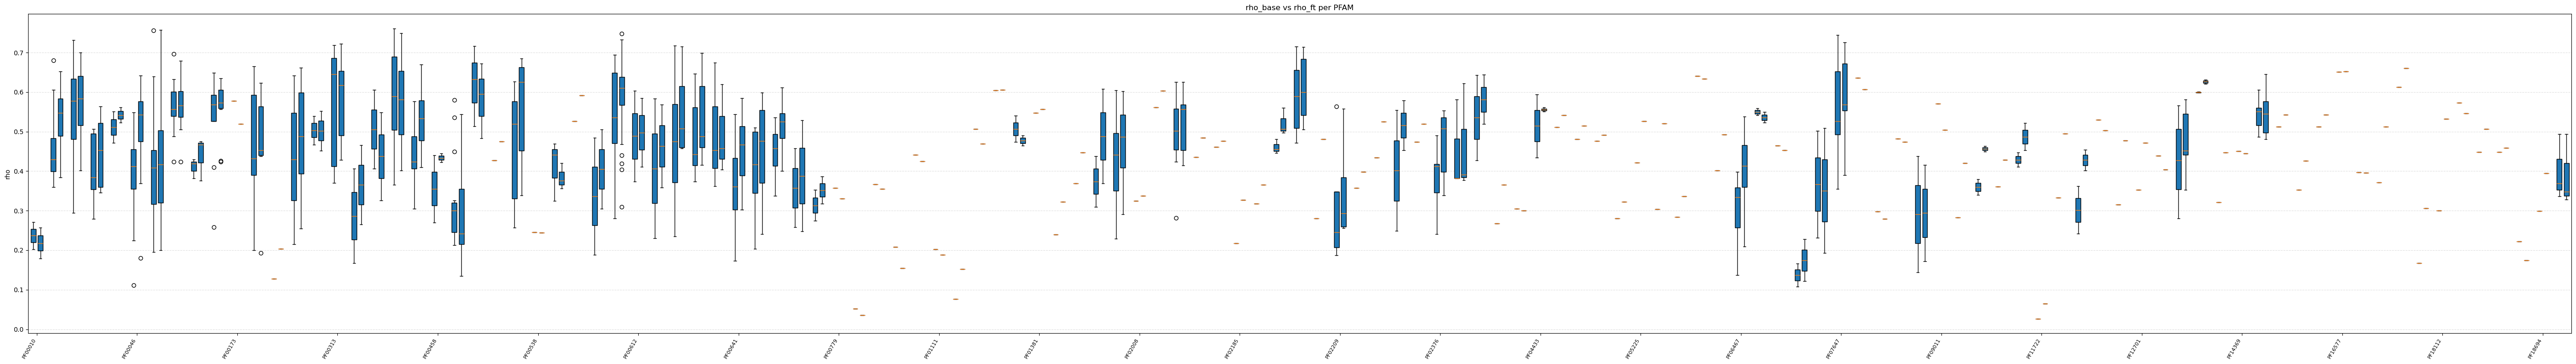

In [23]:
fig, ax = plt.subplots(figsize=(56, 8))

positions_base = np.arange(len(pfams)) * 2
positions_ft = positions_base + 0.7

# Boxplots
ax.boxplot(
    base_data,
    positions=positions_base,
    widths=0.5,
    patch_artist=True
)

ax.boxplot(
    ft_data,
    positions=positions_ft,
    widths=0.5,
    patch_artist=True
)

# Show only every nth label
step = 5

ax.set_xticks((positions_base + 0.35)[::step])
ax.set_xticklabels(
    np.array(pfams)[::step],
    rotation=60,
    ha='right',
    fontsize=8
)

ax.set_ylabel("rho")
ax.set_title("rho_base vs rho_ft per PFAM")

# Light grid
ax.grid(axis='y', linestyle='--', alpha=0.4)

# Reduce empty margins
ax.margins(x=0.005)

plt.tight_layout()
plt.show()

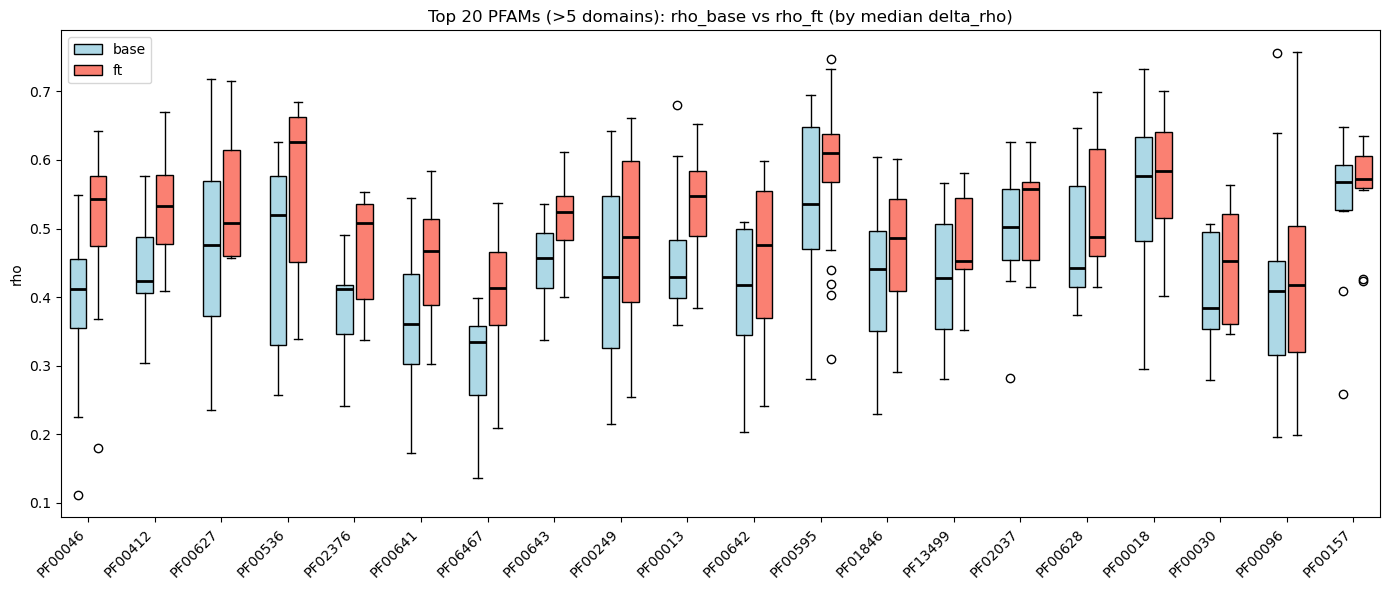

In [24]:
# --- Step 1: filter PFAMs with enough samples ---
pfam_counts = corr_df['pfam'].value_counts()
valid_pfams = pfam_counts[pfam_counts > 5].index
df_filt = corr_df[corr_df['pfam'].isin(valid_pfams)].copy()

# --- Step 2: select top 20 PFAMs by median delta_rho ---
top_pfams = (
    df_filt.groupby('pfam')['delta_rho']
    .median()
    .sort_values(ascending=False)
    .head(20)
    .index
)

df_top = df_filt[df_filt['pfam'].isin(top_pfams)].copy()

# --- Step 3: reshape for plotting ---
long_df = df_top.melt(
    id_vars=['pfam'],
    value_vars=['rho_base', 'rho_ft'],
    var_name='condition',
    value_name='rho'
)

# --- Step 4: build boxplot data ---
pfams = list(top_pfams)

base_data = []
ft_data = []

for pfam in pfams:
    base_data.append(
        long_df[(long_df['pfam'] == pfam) & (long_df['condition'] == 'rho_base')]['rho']
    )
    ft_data.append(
        long_df[(long_df['pfam'] == pfam) & (long_df['condition'] == 'rho_ft')]['rho']
    )

# --- Step 5: plot ---
fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(pfams)) * 2
x_ft = x + 0.6

ax.boxplot(base_data, positions=x, patch_artist=True, 
           boxprops=dict(facecolor='lightblue'), label='base',
           medianprops=dict(color='black', linewidth=2))
ax.boxplot(ft_data, positions=x_ft, patch_artist=True, 
           boxprops=dict(facecolor='salmon'), label='ft',
           medianprops=dict(color='black', linewidth=2))

ax.set_xticks(x + 0.3)
ax.set_xticklabels(pfams, rotation=45, ha='right')

ax.set_ylabel("rho")
ax.set_title("Top 20 PFAMs (>5 domains): rho_base vs rho_ft (by median delta_rho)")

plt.legend()
plt.tight_layout()
plt.show()

In [27]:
long_df.head()

,pfam,condition,rho
0,PF00595,rho_base,0.378841
1,PF00018,rho_base,0.422455
2,PF00627,rho_base,0.235321
3,PF00046,rho_base,0.320946
4,PF06467,rho_base,0.186344


In [28]:
corr_df[['domain_id', 'n', 'uniprot_id', 'pfam', 'rho_base', 'rho_ft', 'delta_rho']].sort_values('delta_rho', ascending=False).head(20)

,domain_id,n,uniprot_id,pfam,rho_base,rho_ft,delta_rho
520,Q9Y6N9_PF00595_207,1255,Q9Y6N9,PF00595,0.378841,0.626113,0.247273
153,P20936_PF00018_281,1158,P20936,PF00018,0.422455,0.666934,0.244478
350,Q86VP1_PF18112_729,494,Q86VP1,PF18112,0.299746,0.531721,0.231975
155,P22681_PF00627_854,850,P22681,PF00627,0.235321,0.457588,0.222268
472,Q9P0J7_PF05605_76,1093,Q9P0J7,PF05605,0.303563,0.520061,0.216498
452,Q9HA38_PF12171_246,493,Q9HA38,PF12171,0.241383,0.454476,0.213094
304,Q15911_PF00046_2147,1055,Q15911,PF00046,0.320946,0.530777,0.209831
212,P55265_PF02295_296,1147,P55265,PF02295,0.248485,0.452711,0.204227
352,Q86XK2_PF02207_849,867,Q86XK2,PF02207,0.280419,0.481052,0.200633
488,Q9UJ78_PF06467_334,678,Q9UJ78,PF06467,0.186344,0.376822,0.190478


In [29]:
corr_df.head()

,domain_id,uniprot_id,n,rho_base,p_base,rho_ft,p_ft,delta_rho,pfam
520,Q9Y6N9_PF00595_207,Q9Y6N9,1255,0.378841,4.165029e-44,0.626113,1.456364e-137,0.247273,PF00595
153,P20936_PF00018_281,P20936,1158,0.422455,2.486852e-51,0.666934,6.875281e-150,0.244478,PF00018
350,Q86VP1_PF18112_729,Q86VP1,494,0.299746,1.029321e-11,0.531721,2.119634e-37,0.231975,PF18112
155,P22681_PF00627_854,P22681,850,0.235321,3.693812e-12,0.457588,3.250431e-45,0.222268,PF00627
472,Q9P0J7_PF05605_76,Q9P0J7,1093,0.303563,9.848891e-25,0.520061,9.076428e-77,0.216498,PF05605


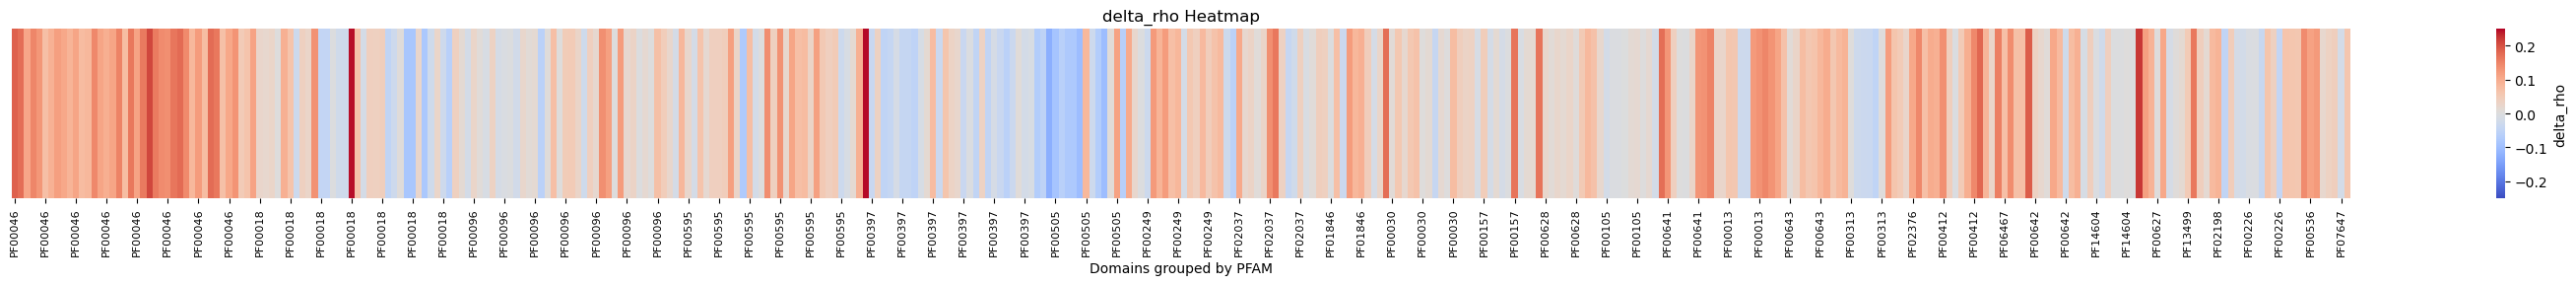

In [31]:
# Count domains per PFAM
pfam_counts = df['pfam'].value_counts()

# Keep only PFAMs with >= 5 domains
valid_pfams = pfam_counts[pfam_counts >= 5].index

filtered = df[df['pfam'].isin(valid_pfams)].copy()

# Order PFAMs by number of domains (descending)
pfam_order = (
    filtered['pfam']
    .value_counts()
    .index
)

# Sort dataframe by PFAM order
filtered['pfam'] = pd.Categorical(
    filtered['pfam'],
    categories=pfam_order,
    ordered=True
)

filtered = filtered.sort_values(['pfam', 'domain_id'])

# Create 1-row heatmap matrix
heatmap_data = np.array([filtered['delta_rho'].values])

# Plot
fig, ax = plt.subplots(figsize=(30, 3))

sns.heatmap(
    heatmap_data,
    cmap='coolwarm',
    center=0,
    vmin=-0.25,
    vmax=0.25,
    cbar_kws={'label': 'delta_rho'},
    xticklabels=filtered['pfam'].values,
    yticklabels=[],
    ax=ax
)

# Reduce x tick clutter
step = 5
ticks = np.arange(len(filtered))[::step]

ax.set_xticks(ticks + 0.5)
ax.set_xticklabels(
    filtered['pfam'].values[::step],
    rotation=90,
    fontsize=8
)

ax.set_xlabel("Domains grouped by PFAM")
ax.set_title("delta_rho Heatmap")

plt.tight_layout()
plt.show()

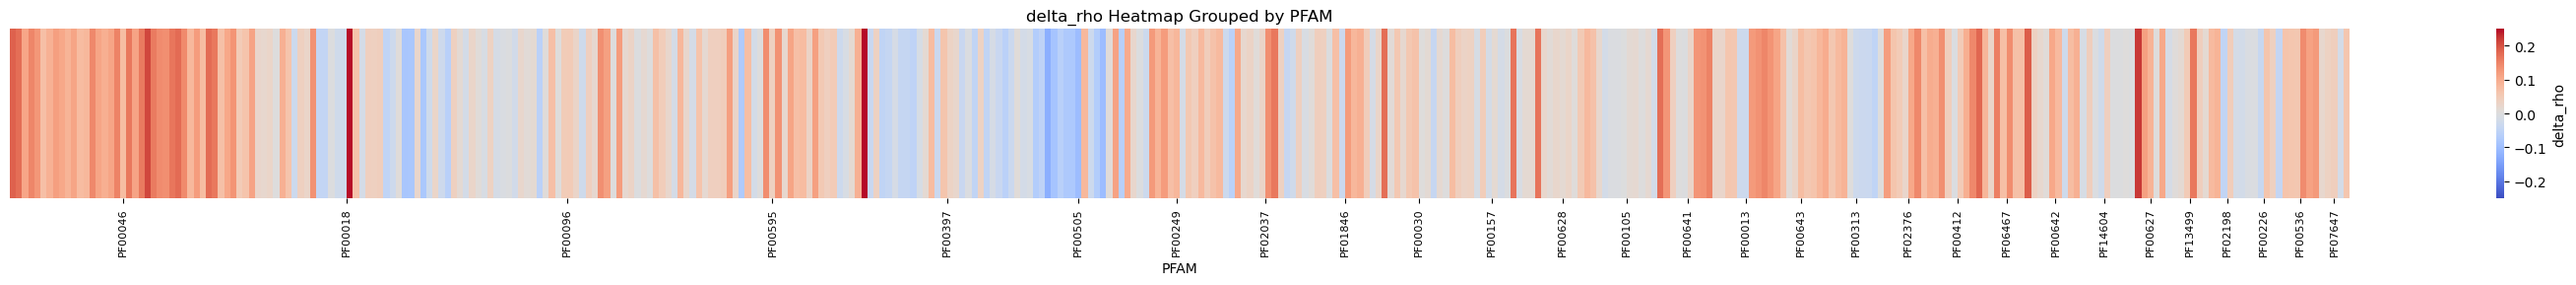

In [32]:
# Count domains per PFAM
pfam_counts = df['pfam'].value_counts()

# Keep only PFAMs with >= 5 domains
valid_pfams = pfam_counts[pfam_counts >= 5].index

filtered = df[df['pfam'].isin(valid_pfams)].copy()

# Order PFAMs by number of domains (descending)
pfam_order = (
    filtered['pfam']
    .value_counts()
    .index
)

# Set categorical ordering
filtered['pfam'] = pd.Categorical(
    filtered['pfam'],
    categories=pfam_order,
    ordered=True
)

# Sort by PFAM then domain
filtered = filtered.sort_values(['pfam', 'domain_id'])

# Heatmap data
heatmap_data = np.array([filtered['delta_rho'].values])

# Plot
fig, ax = plt.subplots(figsize=(30, 3))

sns.heatmap(
    heatmap_data,
    cmap='coolwarm',
    center=0,
    vmin=-0.25,
    vmax=0.25,
    cbar_kws={'label': 'delta_rho'},
    xticklabels=False,
    yticklabels=[],
    ax=ax
)

# Compute centered tick positions for each PFAM block
tick_positions = []
tick_labels = []

start = 0

for pfam in pfam_order:
    count = (filtered['pfam'] == pfam).sum()

    center = start + count / 2
    tick_positions.append(center)
    tick_labels.append(pfam)

    start += count

# Set centered PFAM labels
ax.set_xticks(tick_positions)
ax.set_xticklabels(
    tick_labels,
    rotation=90,
    fontsize=8
)

ax.set_xlabel("PFAM")
ax.set_title("delta_rho Heatmap Grouped by PFAM")

plt.tight_layout()
plt.show()

In [35]:
filename = "ESM2_ft_all_sp_df.csv.gz"

buffer = BytesIO()

with gzip.GzipFile(fileobj=buffer, mode="wb") as gz:
    gz.write(
        corr_df.to_csv(index=False).encode("utf-8")
    )

buffer.seek(0)

# Upload directly to GCS
bucket_name = GCS_BUCKET
destination_blob = f"{GCS_OUTPUT_PREFIX}{RUN_ID}/{filename}"

client = storage.Client()
bucket = client.bucket(bucket_name)
blob = bucket.blob(destination_blob)

blob.upload_from_file(
    buffer,
    content_type="application/gzip"
)

print(f"Uploaded to gs://{bucket_name}/{destination_blob}")

Uploaded to gs://domainome-data/ESM2/ft_all_doms_run2/global_finetune/ESM2_ft_all_sp_df.csv.gz
